In [1]:
import tensorflow as tf
tf.keras.backend.clear_session()

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

y_train = y_train.flatten()
y_test = y_test.flatten()

x_train = x_train[:5000]
y_train = y_train[:5000]
x_test = x_test[:1000]
y_test = y_test[:1000]

In [ ]:
def preprocess(image, label):
    image = tf.image.resize(image, (224, 224))
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label

batch_size = 8  

train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_ds = train_ds.map(preprocess).batch(batch_size).shuffle(500)

test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_ds = test_ds.map(preprocess).batch(batch_size)

In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False 

In [5]:
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(10, activation='softmax')
])

In [6]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=5
)

Epoch 1/5


625/625 [==============================] - 82s 122ms/step - loss: 1.1117 - accuracy: 0.6234 - val_loss: 0.6470 - val_accuracy: 0.7850
Epoch 2/5
625/625 [==============================] - 84s 133ms/step - loss: 0.7206 - accuracy: 0.7530 - val_loss: 0.6114 - val_accuracy: 0.7950
Epoch 3/5
625/625 [==============================] - 77s 120ms/step - loss: 0.6012 - accuracy: 0.7902 - val_loss: 0.5761 - val_accuracy: 0.8080
Epoch 4/5
625/625 [==============================] - 90s 142ms/step - loss: 0.5385 - accuracy: 0.8098 - val_loss: 0.6246 - val_accuracy: 0.7820
Epoch 5/5
625/625 [==============================] - 80s 126ms/step - loss: 0.4935 - accuracy: 0.8216 - val_loss: 0.5657 - val_accuracy: 0.8130


In [8]:
loss, acc = model.evaluate(test_ds)
print("Test Accuracy:", acc)

125/125 [==============================] - 12s 91ms/step - loss: 0.5657 - accuracy: 0.8130
Test Accuracy: 0.8130000233650208


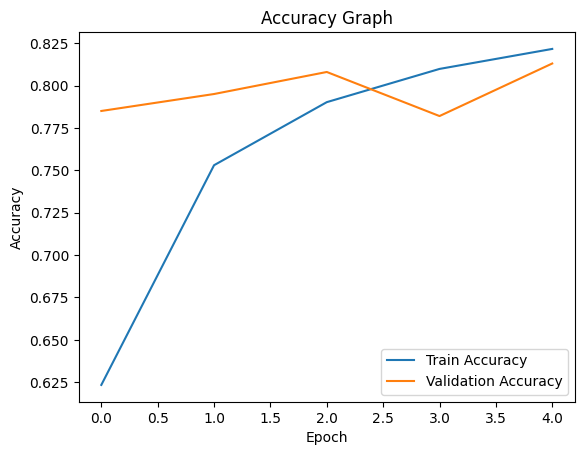

In [9]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Graph')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

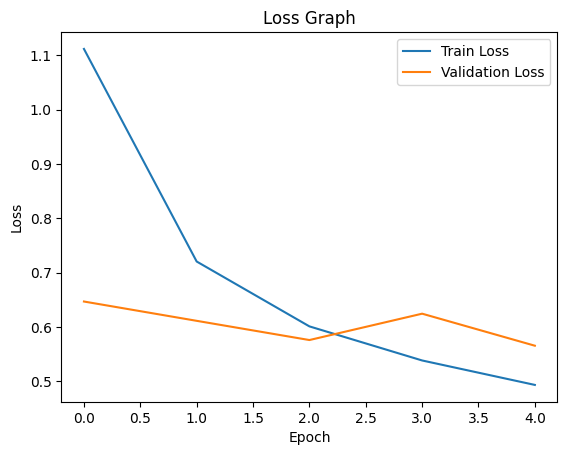

In [10]:
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Graph')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()